In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import gsw
from sklearn.mixture import GaussianMixture
from funcs import cross_sec_lon, cross_sec_lon_prob, cross_sec_lon_prob2, calc_pv, method34

In [3]:
# Get data into dataframe
df = pd.read_csv('../../WMA_fractions_v2.csv', skiprows=1)

# Preprocess data to contain the relevant features
df_ST = df.copy()
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','Datetime_[UTC]','Profile_Number']]
df_ST['year'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.year
df_ST['month'] = pd.to_datetime(df_ST['Datetime_[UTC]']).dt.month
df_ST = df_ST[df_ST['year'] >= 1980] # remove the few points before 1980 (only 7 points)
df_ST = df_ST[['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]', 'Dissolved_Oxygen_[micro_mol_per_kg]', 
               'Depth_[m]', 'Latitude_[deg_N]', 'Longitude_[deg_E]','year', 'month','Profile_Number']]

# # Calculate potential vorticity
# df_ST = calc_pv(df_ST)

In [4]:
# Define random master seed for reproducibility
master_seed = 22
random.seed(master_seed)

# Ensemble size
ensemble_size = 20

# Define a list of random seeds
seeds = random.sample(range(1, 10000), ensemble_size)

In [5]:
# Define features to use for clustering
features = ['Conservative_Temperature_[deg_C]', 'Absolute_Salinity_[PSU]']

In [6]:
df_sampled = method34(df=df_ST, seed=master_seed)

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:956: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [7]:
# Do BIC and AIC calculation for different number of clusters and for 10 different seeds
all_scores = {}
all_aic_scores = {}
n_components_range = range(1, 8)
for i,seed in enumerate(seeds):
    bic_scores = [] 
    aic_scores = []
    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=seed) # full cov matrix has more flexibility
        gmm.fit(df_sampled[features])
        bic_scores.append(gmm.bic(df_sampled[features]))
        aic_scores.append(gmm.aic(df_sampled[features]))

    all_scores[i] = bic_scores
    all_aic_scores[i] = aic_scores

Text(0.5, 1.0, 'BIC Scores for GMM with Different Number of Components and Seeds')

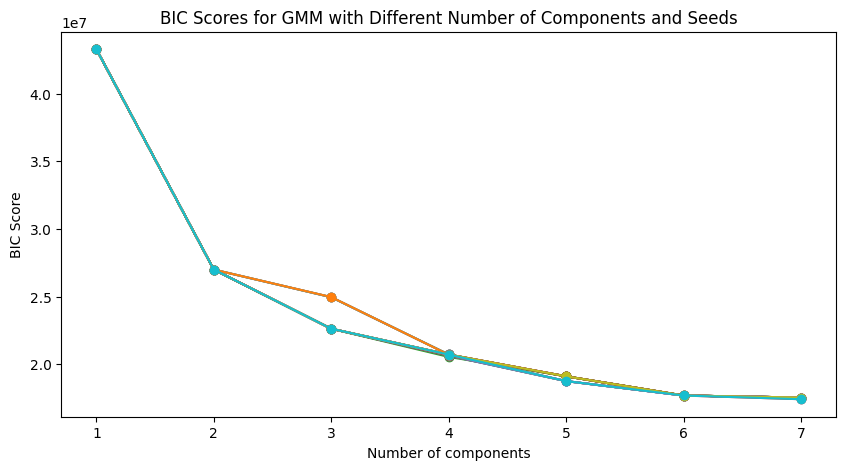

In [8]:
plt.figure(figsize=(10,5))
for i in range(ensemble_size):
    plt.plot(n_components_range, all_scores[i], label=f'Seed {seeds[i]}', marker='o')
plt.xlabel('Number of components')
plt.ylabel('BIC Score')
plt.title('BIC Scores for GMM with Different Number of Components and Seeds')
# plt.legend(loc='lower left')

In [9]:
# Choice of optimal number of clusters based on BIC
n_clusters = 6

In [10]:
gmms = []
labels = [] 
for i,seed in enumerate(seeds):
    gmm = GaussianMixture(
        n_components=n_clusters,          # number of clusters
        covariance_type='full',  # full cov matrix has more flexibility
        random_state=seed)
    gmm.fit(df_sampled[features])
    gmms.append(gmm)
    labels.append(gmm.predict(df_sampled[features]))

In [82]:
# Preprocess for comparrison of cluster labels across different seeds
# Clusters with similar mean T, S and D (depth) should be matched across different seeds
cluster_means = []
for i in range(ensemble_size):
    means = gmms[i].means_
    cluster_means.append(means)

# Match clusters across different seeds based on closest mean T, S and D (depth)
matched_labels = []
for i in range(ensemble_size):
    means = cluster_means[i]
    matched = np.zeros(n_clusters, dtype=int)
    for j in range(n_clusters):
        mean_T = means[j, 0]
        mean_S = means[j, 1]
        min_dist = np.inf
        match = -1
        for k in range(n_clusters):
            dist = np.sqrt((mean_T - cluster_means[0][k, 0])**2 + (mean_S - cluster_means[0][k, 1])**2)
            if dist < min_dist:
                min_dist = dist
                match = k
        matched[j] = match
    matched_labels.append(matched)

In [12]:
# Add matched cluster labels to the dataframe
for i in range(ensemble_size):
    labels = gmms[i].predict(df_sampled[features])
    df_sampled['gmm_label_'+str(i)] = matched_labels[i][labels]

In [13]:
def cluster_overlap(df):
    """
    Compute overlap between aligned clusters across an ensemble of GMMs. 
    Create a mean cluster to use as reference.
    
    Parameters:
    - df: dataframe with columns for each GMM in the ensemble, 
        where each column contains the cluster labels for that GMM.

    Returns:
    - dict with overlap statistics for each aligned cluster.
    """

    # compute mode cluster labels across ensemble to use as reference
    mean_clusters = df[[f'gmm_label_{i}' for i in range(ensemble_size)]].mean(axis=1).round().astype(int)
    df['mean_cluster'] = mean_clusters # add mean cluster labels to dataframe
    
    n_clusters = len(set(df['gmm_label_0']))  # All have same number of clusters
    overlap_results = {}

    for k in range(n_clusters):

        cluster_k_mask = mean_clusters == k

        overlaps = []

        for i in range(1, ensemble_size):
            cluster_i_mask = df[f'gmm_label_{i}'] == k
            overlap_fraction = np.sum(cluster_k_mask & cluster_i_mask) / np.sum(cluster_k_mask)
            overlaps.append(overlap_fraction)

        overlap_results[k] = {
            "mean_overlap_fraction": np.mean(overlaps),
            "std_overlap_fraction": np.std(overlaps),
            "overlap_fractions": overlaps
        }

    return overlap_results, df

In [14]:
overlap, df_sampled = cluster_overlap(df_sampled)

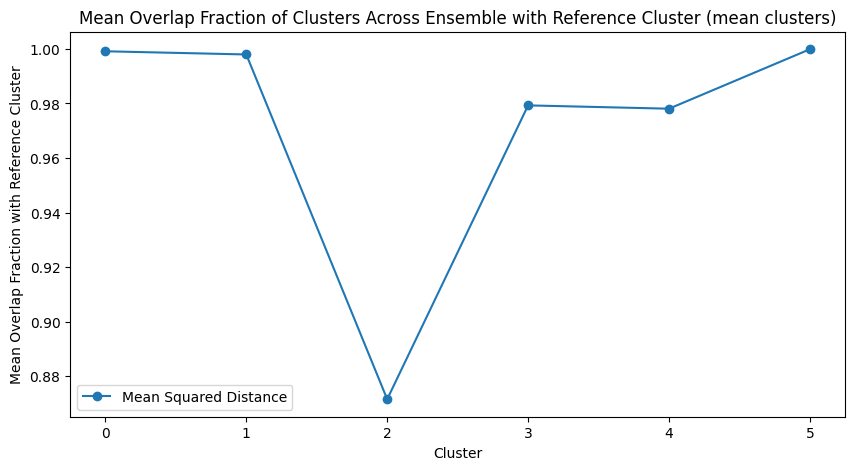

In [15]:
plt.figure(figsize=(10,5))
plt.plot(range(n_clusters), [overlap[k]['mean_overlap_fraction'] for k in range(n_clusters)], label='Mean Squared Distance', marker='o')
plt.xlabel('Cluster')
plt.ylabel('Mean Overlap Fraction with Reference Cluster')
plt.title('Mean Overlap Fraction of Clusters Across Ensemble with Reference Cluster (mean clusters)')
plt.legend()
plt.show()

In [69]:
df_copy = df_sampled.copy()
df_copy['gmm_label_6'] = df_copy['mean_cluster']

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:626: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



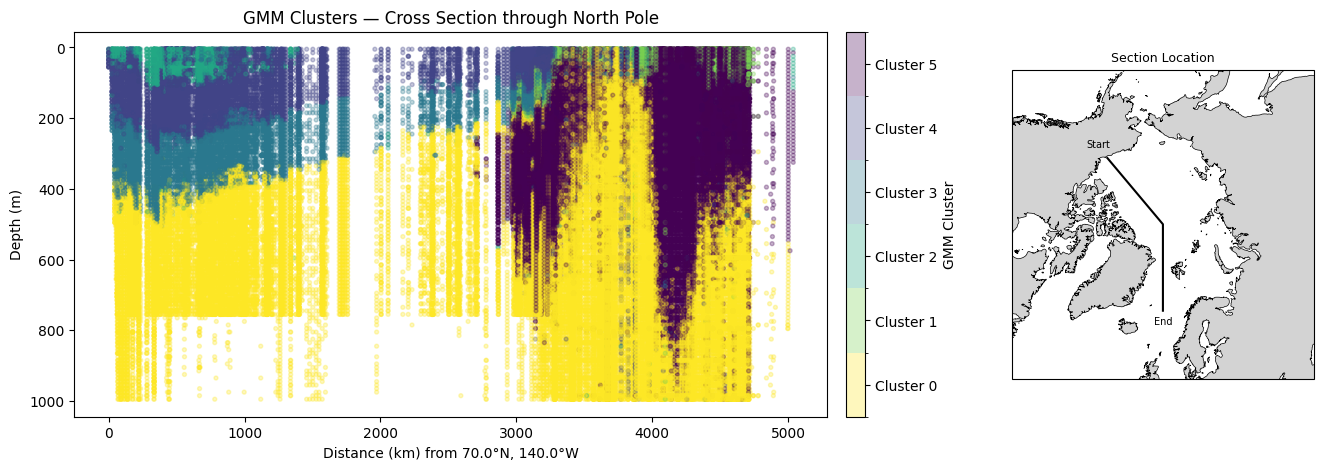

In [70]:
cross_sec_lon(df_copy, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140.0)

In [71]:
df_copy.head()

,Conservative_Temperature_[deg_C],Absolute_Salinity_[PSU],Dissolved_Oxygen_[micro_mol_per_kg],Depth_[m],Latitude_[deg_N],Longitude_[deg_E],year,month,Profile_Number,gmm_label_0,...,gmm_label_11,gmm_label_12,gmm_label_13,gmm_label_14,gmm_label_15,gmm_label_16,gmm_label_17,gmm_label_18,gmm_label_19,mean_cluster
0,-0.838,35.062,NaN,825.0,78.0,0.000,1986,1,218601,0,...,0,0,0,0,0,0,0,0,0,0
1,0.140,35.086,NaN,245.0,78.0,0.000,1986,1,218601,0,...,0,0,0,0,0,0,0,0,0,0
2,0.038,35.086,NaN,305.0,78.0,1.083,1986,1,218597,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.477,35.058,NaN,505.0,78.0,0.000,1986,1,218601,0,...,0,0,0,0,0,0,0,0,0,0
4,0.063,35.082,NaN,205.0,78.0,1.083,1986,1,218597,0,...,0,0,0,0,0,0,0,0,0,0


In [61]:
matched_labels[3]

array([1, 3, 5, 2, 4, 0])

In [85]:
# find the probabilities of the mean clusters
for i in range(ensemble_size):
    for j in range(n_clusters):
        #print (f'Calculating probabilities for cluster {j} in GMM {i}')
        df_copy[f'prob_cluster_{j}_gmm_{i}'] = gmms[i].predict_proba(df_copy[features])[:, matched_labels[i][j]]

# for j in range(n_clusters):
#     df_copy[f'prob_mean_cluster_{j}'] = df_copy[[f'prob_cluster_{j}_gmm_{i}' for i in range(ensemble_size)]].mean(axis=1)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67531/1803733830.py:5: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67531/1803733830.py:5: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67531/1803733830.py:5: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

In [87]:
df_mean_prob = df_copy[['Longitude_[deg_E]', 'Latitude_[deg_N]', 'Depth_[m]']].copy()
df_mean_prob['prob_mean_cluster_0'] = df_copy[[f'prob_cluster_0_gmm_{i}' for i in range(ensemble_size)]].mean(axis=1)

In [88]:
df_mean_prob.head()

,Longitude_[deg_E],Latitude_[deg_N],Depth_[m],prob_mean_cluster_0
0,0.000,78.0,825.0,0.427392
1,0.000,78.0,245.0,0.417361
2,1.083,78.0,305.0,0.424748
3,0.000,78.0,505.0,0.437790
4,1.083,78.0,205.0,0.428094


In [1]:
df_new_copy = df_mean_prob.copy()
df_new_copy['prob_cluster_0'] = df_mean_prob['prob_mean_cluster_0']

NameError: name 'df_mean_prob' is not defined

In [90]:
df_new_copy['prob_cluster_0'].head()

0    0.427392
1    0.417361
2    0.424748
3    0.437790
4    0.428094
Name: prob_cluster_0, dtype: float64

In [48]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Geod
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

def compute_great_circle_distance_km(lat_ref, lon_ref, lats, lons):
    """Compute distance in km from a reference point along a great circle."""
    geod = Geod(ellps='WGS84')
    _, _, dist_m = geod.inv(
        np.full(len(lats), lon_ref),
        np.full(len(lats), lat_ref),
        lons,
        lats
    )
    return dist_m / 1000.0

def cross_sec_lon_prob2_one(
    df_sampled,
    n_clusters,
    lon_value,
    tol=0.5,
    start_lat=70.0,
    start_lon=-140.0,
    max_depth=850,
    depth_bin_size=10,
    dist_bin_size=2.2):

    # Antipodal longitude for the over-pole extension
    if lon_value < 0 and lon_value >= -180:
        lon_value = lon_value + 180
        
    # Primary slice from start_lon and secondary for lon_value intersecting at the pole
    df_primary = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= start_lon - tol) &
        (df_sampled['Longitude_[deg_E]'] <= start_lon + tol)
    ].copy()

    df_antipodal = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
    ].copy()

    df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

    # Compute great-circle distance from start point
    df_lon_slice['dist_km'] = compute_great_circle_distance_km(
        start_lat, start_lon,
        df_lon_slice['Latitude_[deg_N]'].values,
        df_lon_slice['Longitude_[deg_E]'].values
    )

    # Bin coordinates
    df_lon_slice['depth_bin'] = (
        np.floor(df_lon_slice['Depth_[m]'] / depth_bin_size)
        * depth_bin_size
    )

    df_lon_slice['dist_bin'] = (
        np.floor(df_lon_slice['dist_km'] / dist_bin_size)
        * dist_bin_size
    )

    # Average probabilities within bins
    prob_cols = ['prob_cluster_0']

    df_binned = (
        df_lon_slice
        .groupby(['dist_bin', 'depth_bin'])[prob_cols]
        .mean()
        .reset_index()
    )

    # Regular plotting grid
    xi = np.arange(
        df_binned['dist_bin'].min(),
        df_binned['dist_bin'].max(),
        dist_bin_size
    )

    yi = np.arange(
        0,
        max_depth + depth_bin_size,
        depth_bin_size
    )

    XI, YI = np.meshgrid(xi, yi)

    # Figure
    fig = plt.figure(figsize=(24, 16))
    gs = fig.add_gridspec(int(np.floor(1)), int(np.floor(2)), 
                            width_ratios=[1,0.1], wspace=0.4, hspace=0.5)

    axes = []
    for i in range(int(np.floor(1))):
        for j in range(int(1)):
            axes.append(fig.add_subplot(gs[i, j]))

    cax = fig.add_subplot(gs[:, 1])
    # Plot each field
    ax = axes[0]  # Just plotting the first one for demonstration
    col = f'prob_cluster_0'
    # Interpolate onto regular grid
    ZI = griddata(
        (
            df_binned['dist_bin'],
            df_binned['depth_bin']
        ),
        df_binned[col] * 100,
        (XI, YI),
        method='linear'
    )

    # Smooth field
    ZI = gaussian_filter(ZI, sigma=1.0)

    # Plot
    pcm = ax.pcolormesh(
        XI,
        YI,
        ZI,
        shading='auto',
        cmap='viridis',
        vmin=0,
        vmax=100)

    # Pole marker
    ax.axvline(
        2200,
        color='white',
        linestyle='--',
        linewidth=1)

    # Formatting
    ax.set_ylim(max_depth, 0)
    ax.set_title(f'Cluster 0 Mean Probability')
    ax.set_xlabel(f'Distance (km) from 70°N, 140°W')
    ax.set_ylabel('Depth (m)')

    # Shared colorbar
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label('Probability (%)', fontsize=12)

    # Title
    fig.suptitle(
        'GMM Cluster Probabilities — Cross Section through North Pole',
        fontsize=5,
        y=0.98
    )

    plt.tight_layout()
    plt.show()


/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_67531/3544042270.py:152: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



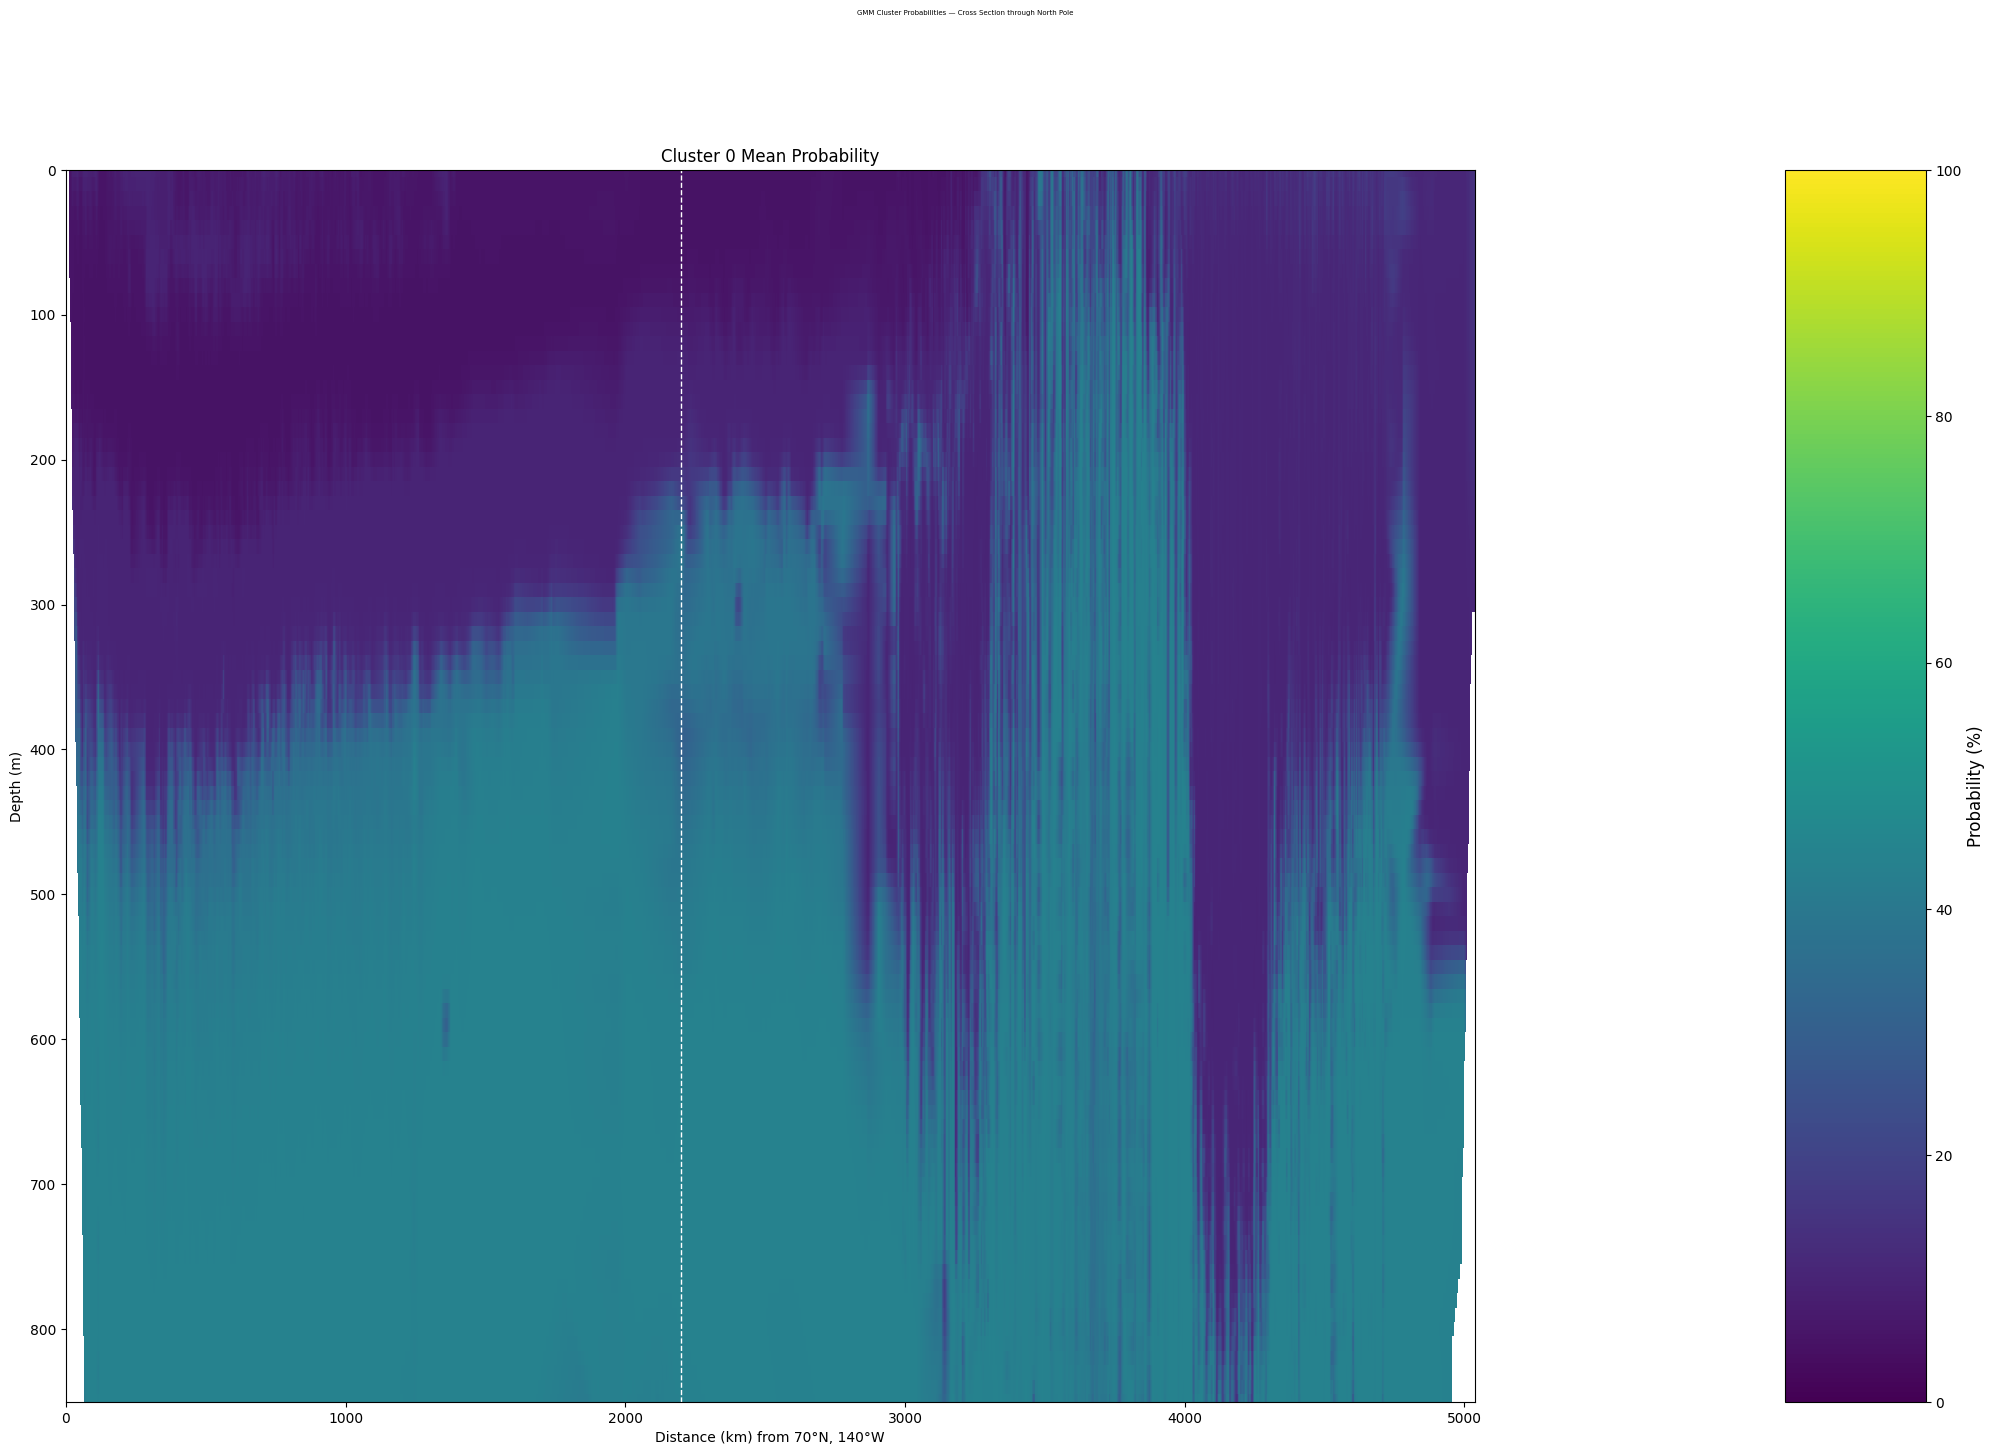

In [91]:
cross_sec_lon_prob2_one(df_new_copy, 1, 0, tol=0.5, start_lat=70.0, start_lon=-140)

In [24]:
df_labels = df_copy[['Longitude_[deg_E]', 'Latitude_[deg_N]', 'Depth_[m]']].copy()
for i in range(ensemble_size):
    df_labels[f'label_gmm_{i}'] = df_copy[f'gmm_label_{i}']

In [25]:
df_labels.head()

,Longitude_[deg_E],Latitude_[deg_N],Depth_[m],label_gmm_0,label_gmm_1,label_gmm_2,label_gmm_3,label_gmm_4,label_gmm_5,label_gmm_6,...,label_gmm_10,label_gmm_11,label_gmm_12,label_gmm_13,label_gmm_14,label_gmm_15,label_gmm_16,label_gmm_17,label_gmm_18,label_gmm_19
0,1.083,78.0,25.0,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
1,1.083,78.0,105.0,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
2,0.000,78.0,145.0,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3
3,0.000,78.0,15.0,5,5,5,5,5,5,5,...,5,5,5,5,5,5,5,5,5,5
4,1.083,78.0,75.0,3,3,3,3,3,3,3,...,3,3,3,3,3,3,3,3,3,3


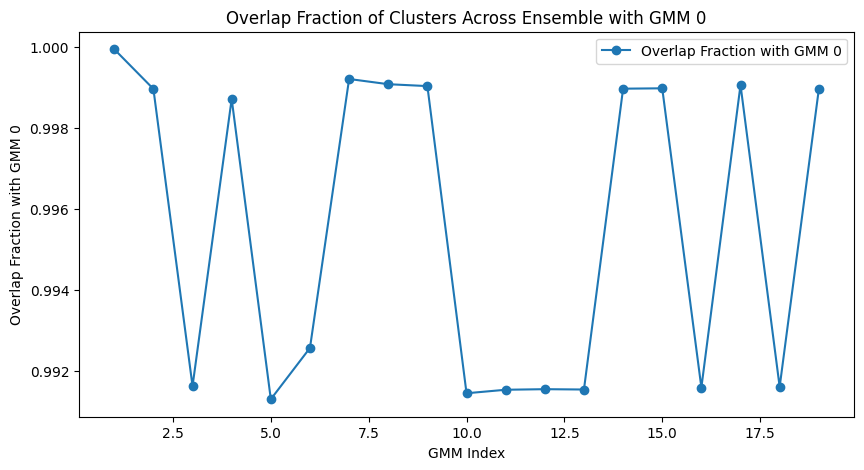

In [49]:
# Check how much they overlap compared to gmm 0
overlap = []
for i in range(1, ensemble_size):
    overlap_fraction = np.sum(df_copy['gmm_label_0'] == df_copy[f'gmm_label_{i}']) / len(df_copy)
    overlap.append(overlap_fraction)

plt.figure(figsize=(10,5))  
plt.plot(range(1, ensemble_size), overlap, label='Overlap Fraction with GMM 0', marker='o')
plt.xlabel('GMM Index')
plt.ylabel('Overlap Fraction with GMM 0')
plt.title('Overlap Fraction of Clusters Across Ensemble with GMM 0')
plt.legend()
plt.show()

In [26]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Geod
from matplotlib.colors import ListedColormap, BoundaryNorm

def compute_great_circle_distance_km(lat_ref, lon_ref, lats, lons):
    """Compute distance in km from a reference point along a great circle."""
    geod = Geod(ellps='WGS84')
    _, _, dist_m = geod.inv(
        np.full(len(lats), lon_ref),
        np.full(len(lats), lat_ref),
        lons,
        lats
    )
    return dist_m / 1000.0

def cross_sec_lon(df_sampled, n_clusters, lon_value, tol=0.5, start_lat=70.0, start_lon=-140.0, col_name='gmm_label_6'):

    # Primary slice from start_lon and secondary for lon_value intersecting at the pole
    df_primary = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= start_lon - tol) &
        (df_sampled['Longitude_[deg_E]'] <= start_lon + tol)
    ].copy()

    df_antipodal = df_sampled[
        (df_sampled['Longitude_[deg_E]'] >= lon_value - tol) &
        (df_sampled['Longitude_[deg_E]'] <= lon_value + tol)
    ].copy()

    df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

    # Compute great-circle distance from start point
    df_lon_slice['dist_km'] = compute_great_circle_distance_km(
        start_lat, start_lon,
        df_lon_slice['Latitude_[deg_N]'].values,
        df_lon_slice['Longitude_[deg_E]'].values
    )

    # ── Colormap (GMM labels) ─────────────────────────────────────────────────
    n = n_clusters
    base_cmap = plt.cm.viridis_r
    colors = base_cmap(np.linspace(0, 1, n))
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(-0.5, n + 0.5, 1), cmap.N)

    # ── Side-by-side layout ───────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.05)

    ax = fig.add_subplot(gs[0])
    ax_map = fig.add_subplot(gs[1], projection=ccrs.NorthPolarStereo())

    # ── Cross-section scatter plot ────────────────────────────────────────────
    sc = ax.scatter(
        df_lon_slice['dist_km'],
        df_lon_slice['Depth_[m]'],
        c=df_lon_slice[col_name],
        cmap=cmap,
        norm=norm,
        s=8,
        alpha=0.3
    )

    ax.invert_yaxis()
    ax.set_xlabel(f'Distance (km) from {start_lat}°N, {abs(start_lon)}°W')
    ax.set_ylabel('Depth (m)')
    ax.set_title('GMM Clusters — Cross Section through North Pole')

    # Discrete colorbar
    cbar = plt.colorbar(sc, ax=ax, pad=0.02)
    cbar.set_ticks(range(n))
    cbar.set_ticklabels([f'Cluster {i}' for i in range(n)])
    cbar.set_label('GMM Cluster')

    # ── Polar map ─────────────────────────────────────────────────────────────
    ax_map.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
    ax_map.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
    ax_map.add_feature(cfeature.OCEAN, facecolor='white', zorder=0)
    ax_map.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=2)

    # Section track: start → pole → antipodal end
    end_lat = start_lat
    end_lon = lon_value
    lats_track = [start_lat, 90.0, end_lat]
    lons_track = [start_lon, lon_value, end_lon]

    ax_map.plot(lons_track, lats_track,
                color='black', linewidth=1.5,
                transform=ccrs.Geodetic(), zorder=3)

    ax_map.text(start_lon, start_lat - 3, 'Start',
                transform=ccrs.PlateCarree(),
                fontsize=7, ha='center', color='black')
    ax_map.text(end_lon, end_lat - 3, 'End',
                transform=ccrs.PlateCarree(),
                fontsize=7, ha='center', color='black')

    ax_map.set_title('Section Location', fontsize=9)

    plt.tight_layout()
    plt.show()

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_15425/996771623.py:100: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



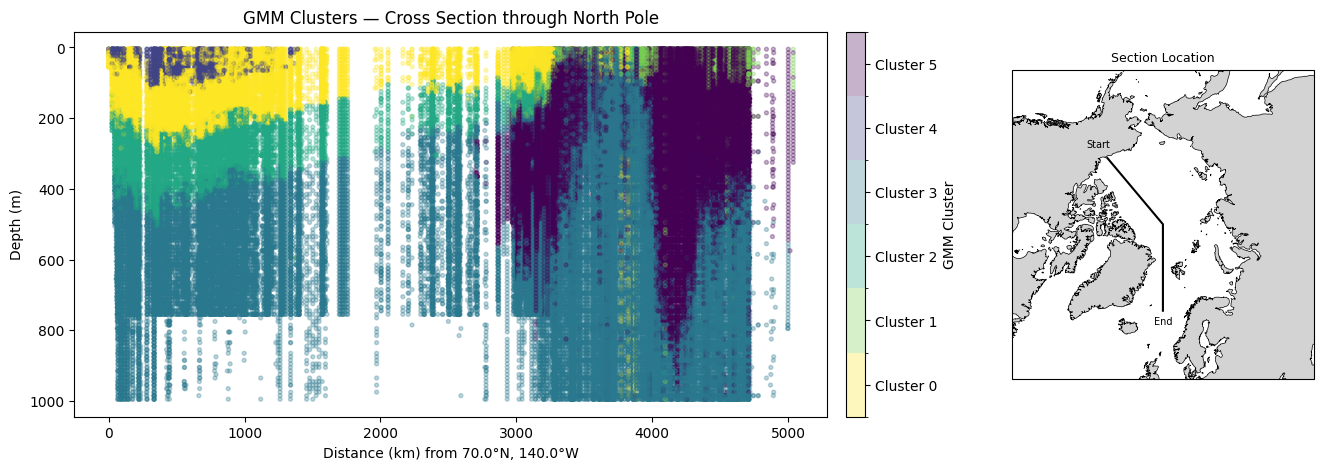

In [28]:
cross_sec_lon(df_labels, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140.0, col_name='label_gmm_0')

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_15425/996771623.py:100: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



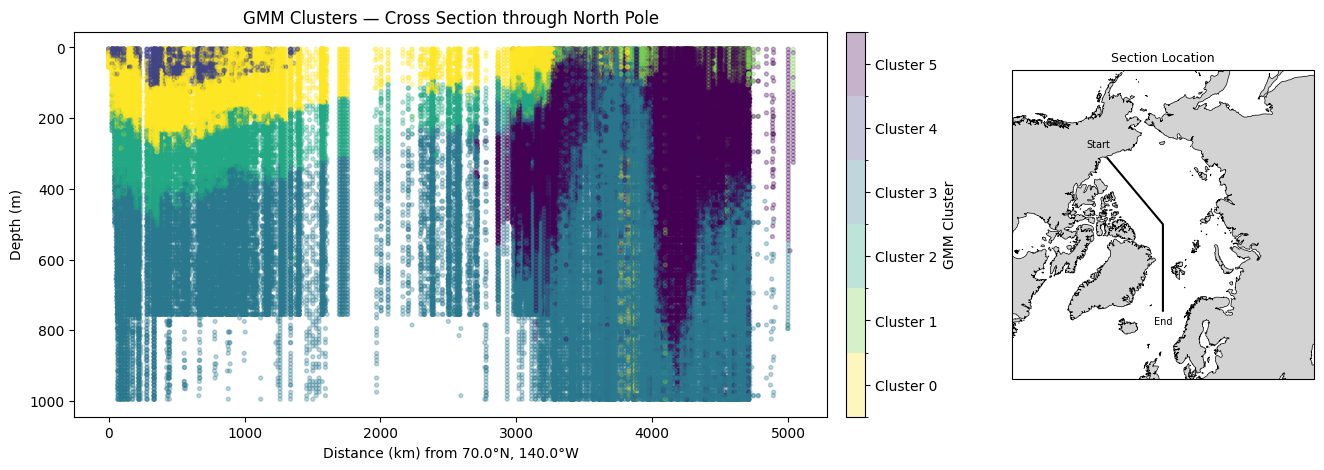

In [29]:
cross_sec_lon(df_labels, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140.0, col_name='label_gmm_1')

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_15425/996771623.py:100: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



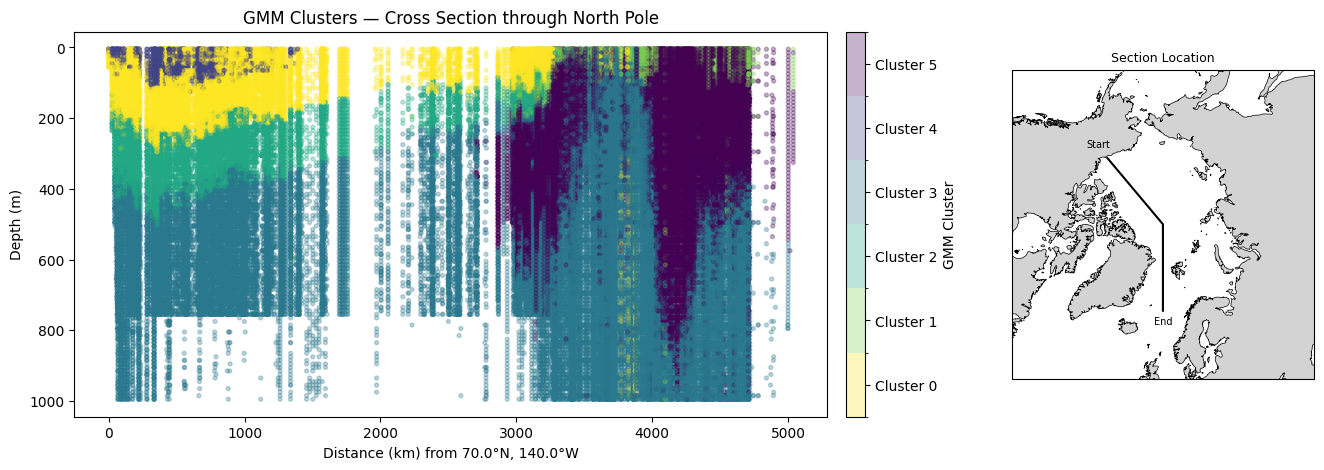

In [30]:
cross_sec_lon(df_labels, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140.0, col_name='label_gmm_2')

In [33]:
df_labels['diff_label_0_2'] = df_labels['label_gmm_0'] - df_labels['label_gmm_']

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_15425/996771623.py:100: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



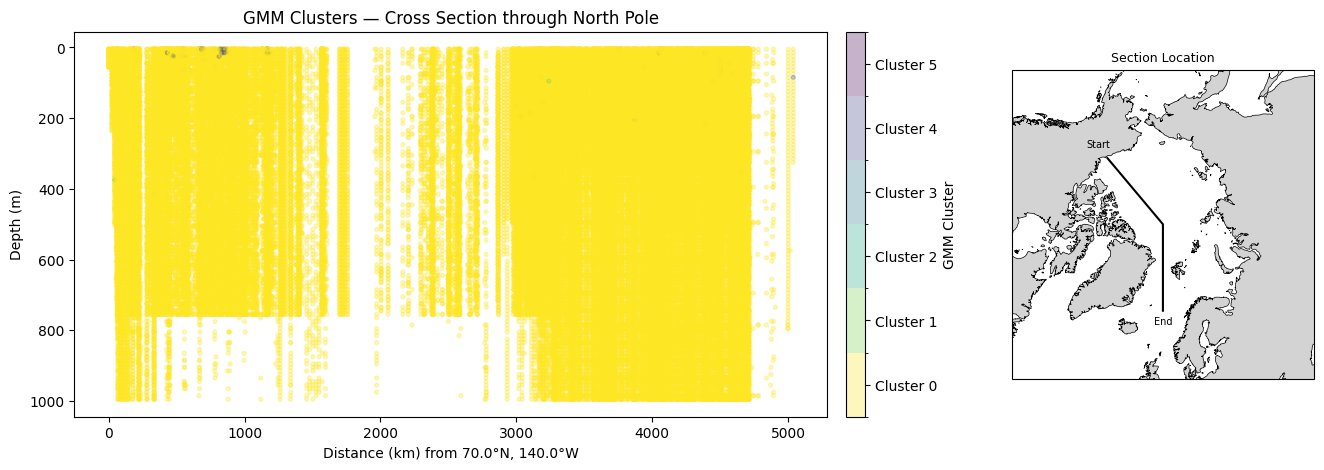

In [34]:
cross_sec_lon(df_labels, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140.0, col_name='diff_label_0_2')

In [17]:
# find the probabilities of the mean clusters
for i in range(ensemble_size):
    for j in range(n_clusters):
        df_copy[f'prob_cluster_{j}_gmm_{i}'] = gmms[i].predict_proba(df_copy[features])[:, j]

for j in range(n_clusters):
    df_copy[f'prob_mean_cluster_{j}'] = df_copy[[f'prob_cluster_{j}_gmm_{i}' for i in range(ensemble_size)]].mean(axis=1)

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_15425/2337038594.py:4: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_15425/2337038594.py:4: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_15425/2337038594.py:4: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

In [86]:
# # match the probabilities to the correct clusters
# for i in range(ensemble_size):
#     for j in range(n_clusters):
#         df_copy[f'prob_cluster_{j}_gmm_{i}'] = df_copy[f'prob_cluster_{matched_labels[i][j]}_gmm_{i}']

In [35]:
df_probs = df_copy[['Longitude_[deg_E]', 'Latitude_[deg_N]', 'Depth_[m]'] + [f'prob_cluster_{i}_gmm_{j}' for i in range(n_clusters) for j in range(ensemble_size)]].copy()

In [36]:
df_probs_0 = df_probs[['Longitude_[deg_E]', 'Latitude_[deg_N]', 'Depth_[m]'] + [f'prob_cluster_0_gmm_{j}' for j in range(ensemble_size)]].copy()

/var/folders/v0/0lp_zzrd33sgh7y2jyh9zzdm0000gn/T/ipykernel_15425/2891222586.py:135: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



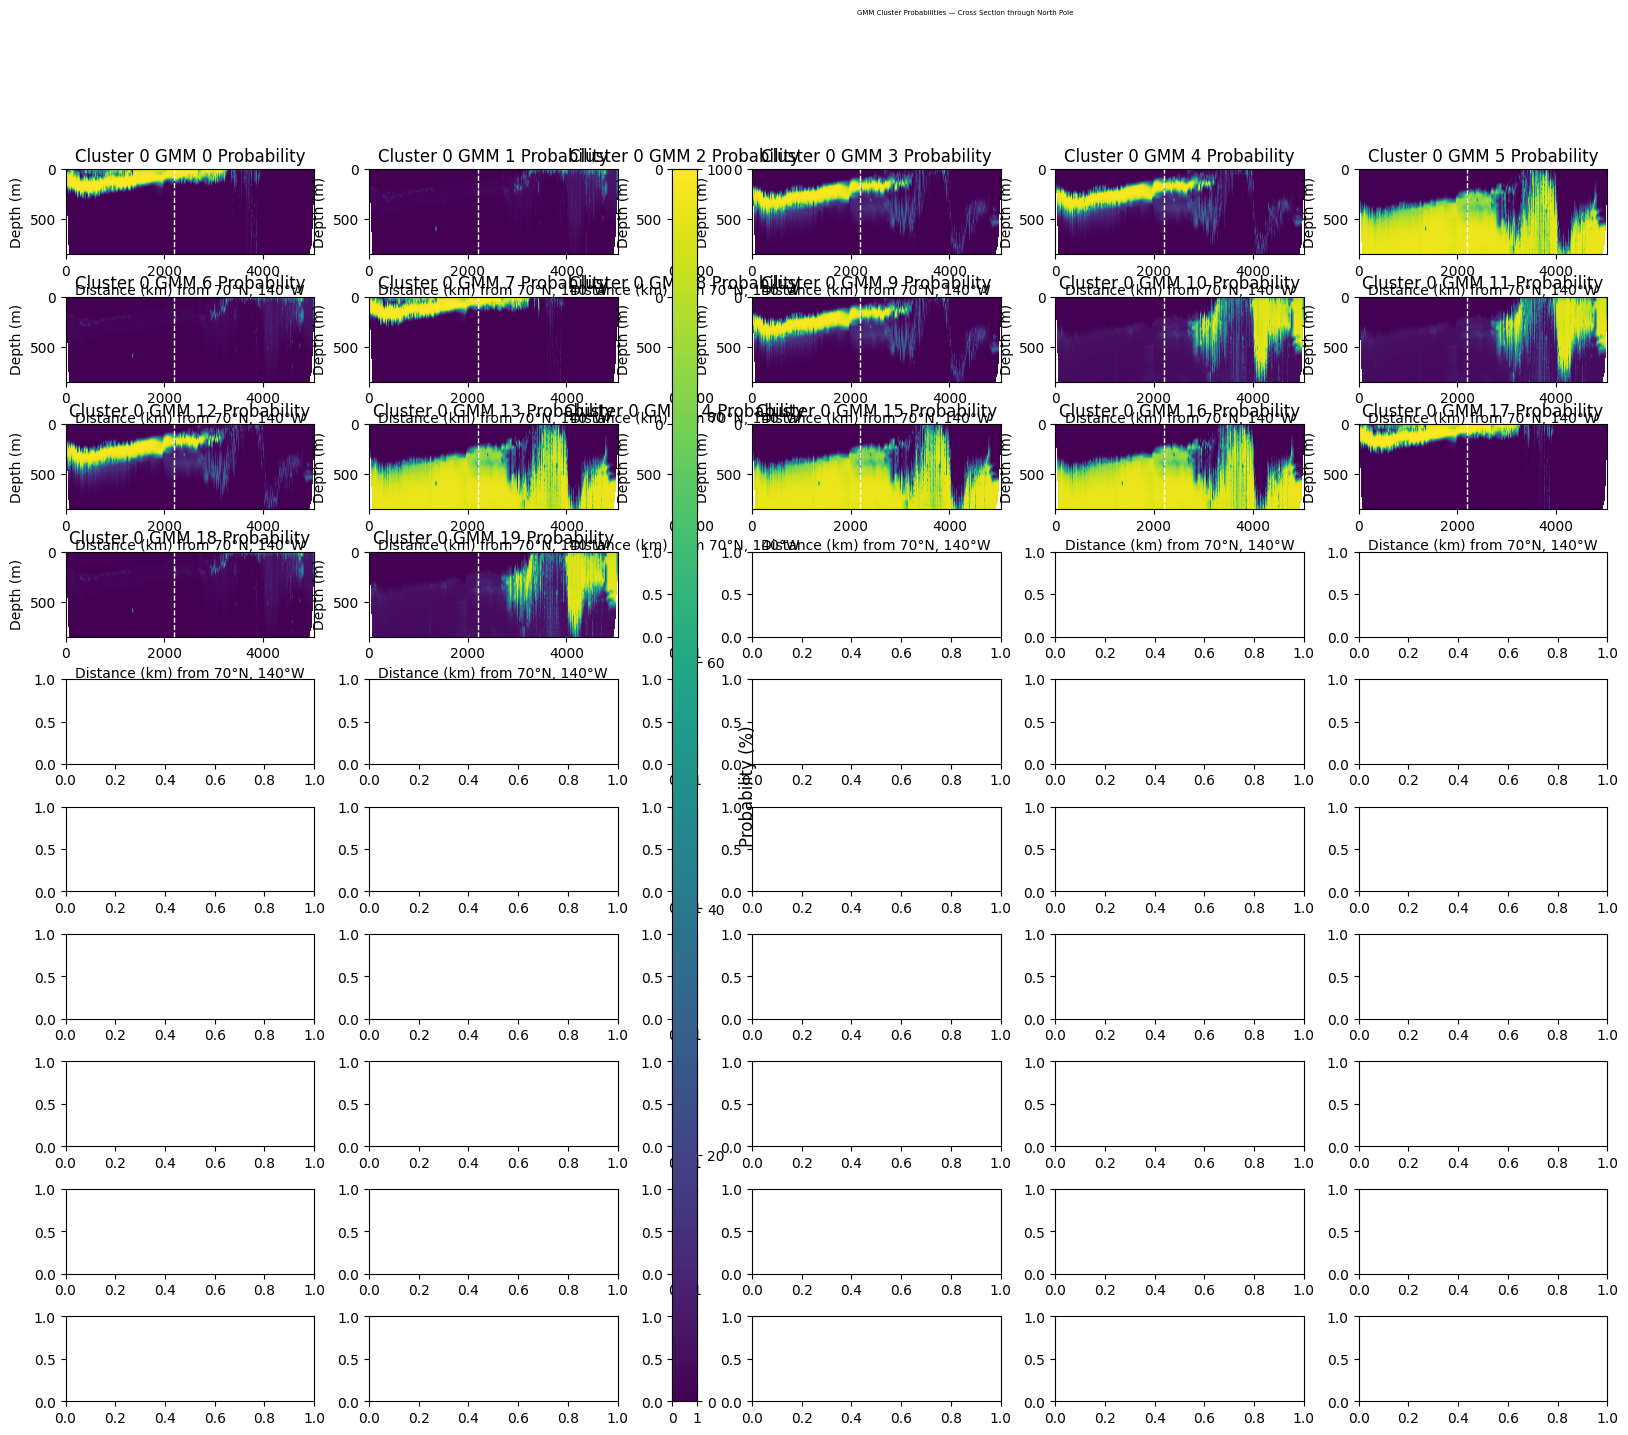

In [47]:
lon_value = 0
start_lat = 70.0
start_lon = -140.0
tol = 0.5
depth_bin_size = 10
dist_bin_size = 2.2
max_depth = 850

from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# Antipodal longitude for the over-pole extension
if lon_value < 0 and lon_value >= -180:
    lon_value = lon_value + 180
    
# Primary slice from start_lon and secondary for lon_value intersecting at the pole
df_primary = df_probs_0[
    (df_probs_0['Longitude_[deg_E]'] >= start_lon - tol) &
    (df_probs_0['Longitude_[deg_E]'] <= start_lon + tol)
].copy()

df_antipodal = df_probs_0[
    (df_probs_0['Longitude_[deg_E]'] >= lon_value - tol) &
    (df_probs_0['Longitude_[deg_E]'] <= lon_value + tol)
].copy()

df_lon_slice = pd.concat([df_primary, df_antipodal], ignore_index=True)

# Compute great-circle distance from start point
df_lon_slice['dist_km'] = compute_great_circle_distance_km(
    start_lat, start_lon,
    df_lon_slice['Latitude_[deg_N]'].values,
    df_lon_slice['Longitude_[deg_E]'].values
)

# Bin coordinates
df_lon_slice['depth_bin'] = (
    np.floor(df_lon_slice['Depth_[m]'] / depth_bin_size)
    * depth_bin_size
)

df_lon_slice['dist_bin'] = (
    np.floor(df_lon_slice['dist_km'] / dist_bin_size)
    * dist_bin_size
)

# Average probabilities within bins
prob_cols = [f'prob_cluster_0_gmm_{i}' for i in range(ensemble_size)]

df_binned = (
    df_lon_slice
    .groupby(['dist_bin', 'depth_bin'])[prob_cols]
    .mean()
    .reset_index()
)

# Regular plotting grid
xi = np.arange(
    df_binned['dist_bin'].min(),
    df_binned['dist_bin'].max(),
    dist_bin_size
)

yi = np.arange(
    0,
    max_depth + depth_bin_size,
    depth_bin_size
)

XI, YI = np.meshgrid(xi, yi)

# Figure
fig = plt.figure(figsize=(24, 16))
gs = fig.add_gridspec(int(np.floor(ensemble_size/2)), int(np.floor(ensemble_size/2)), 
                        width_ratios=[1,1,0.1,1,1,1,0.1,0.1,0.1,0.1], wspace=0.4, hspace=0.5)

axes = []
for i in range(int(np.floor(ensemble_size/2))):
    for j in range(int(np.floor(ensemble_size/3))):
        axes.append(fig.add_subplot(gs[i, j]))

cax = fig.add_subplot(gs[:, 2])
# Plot each field
for i, ax in enumerate(axes):
    if i<ensemble_size:
        col = f'prob_cluster_0_gmm_{i}'
        # Interpolate onto regular grid
        ZI = griddata(
            (
                df_binned['dist_bin'],
                df_binned['depth_bin']
            ),
            df_binned[col] * 100,
            (XI, YI),
            method='linear'
        )

        # Smooth field
        ZI = gaussian_filter(ZI, sigma=1.0)

        # Plot
        pcm = ax.pcolormesh(
            XI,
            YI,
            ZI,
            shading='auto',
            cmap='viridis',
            vmin=0,
            vmax=100)

        # Pole marker
        ax.axvline(
            2200,
            color='white',
            linestyle='--',
            linewidth=1)

        # Formatting
        ax.set_ylim(max_depth, 0)
        ax.set_title(f'Cluster 0 GMM {i} Probability')
        ax.set_xlabel(f'Distance (km) from 70°N, 140°W')
        ax.set_ylabel('Depth (m)')

# Shared colorbar
cbar = fig.colorbar(pcm, cax=cax)
cbar.set_label('Probability (%)', fontsize=12)

# Title
fig.suptitle(
    'GMM Cluster Probabilities — Cross Section through North Pole',
    fontsize=5,
    y=0.98
)

plt.tight_layout()
plt.show()

In [50]:
df_probs_0.head()

,Longitude_[deg_E],Latitude_[deg_N],Depth_[m],prob_cluster_0_gmm_0,prob_cluster_0_gmm_1,prob_cluster_0_gmm_2,prob_cluster_0_gmm_3,prob_cluster_0_gmm_4,prob_cluster_0_gmm_5,prob_cluster_0_gmm_6,...,prob_cluster_0_gmm_10,prob_cluster_0_gmm_11,prob_cluster_0_gmm_12,prob_cluster_0_gmm_13,prob_cluster_0_gmm_14,prob_cluster_0_gmm_15,prob_cluster_0_gmm_16,prob_cluster_0_gmm_17,prob_cluster_0_gmm_18,prob_cluster_0_gmm_19
0,1.083,78.0,25.0,1.858849e-10,0.000848,0.000010,0.000006,0.000010,0.947604,0.000847,...,0.051706,0.051820,0.000006,0.947382,0.944549,0.944557,0.947213,1.860907e-10,0.000881,0.054541
1,1.083,78.0,105.0,2.583411e-10,0.001111,0.000010,0.000005,0.000009,0.934580,0.001109,...,0.064556,0.064713,0.000005,0.934282,0.929785,0.929796,0.934039,2.589850e-10,0.001140,0.069023
2,0.000,78.0,145.0,1.298999e-13,0.007847,0.006751,0.005180,0.006661,0.572536,0.007838,...,0.417803,0.419251,0.005156,0.569983,0.513966,0.514049,0.567433,1.308294e-13,0.007582,0.470980
3,0.000,78.0,15.0,1.044301e-15,0.013776,0.056667,0.052422,0.056246,0.177686,0.013767,...,0.758269,0.759487,0.052303,0.175556,0.131670,0.131722,0.173371,1.042520e-15,0.013985,0.797141
4,1.083,78.0,75.0,3.122144e-10,0.001334,0.000010,0.000005,0.000009,0.924027,0.001332,...,0.074966,0.075159,0.000005,0.923664,0.917708,0.917722,0.923357,3.132718e-10,0.001358,0.080861


In [ ]:
for i in range(ensemble_size):
    df_labels['gmm_label_'+str(i)] = matched_labels[i][labels]

In [18]:
df_new_copy = df_copy.copy()
for i in range(n_clusters):
    df_new_copy['prob_cluster_'+str(i)] = df_copy[f'prob_mean_cluster_{i}']

In [19]:
df_new_copy['prob_cluster_0'].head()

0    0.244642
1    0.243265
2    0.205388
3    0.171736
4    0.242144
Name: prob_cluster_0, dtype: float64

/Users/franciscagomes/PhD/WM_class/WaterMassClassification/Cluster_n_sensitivity/funcs.py:859: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



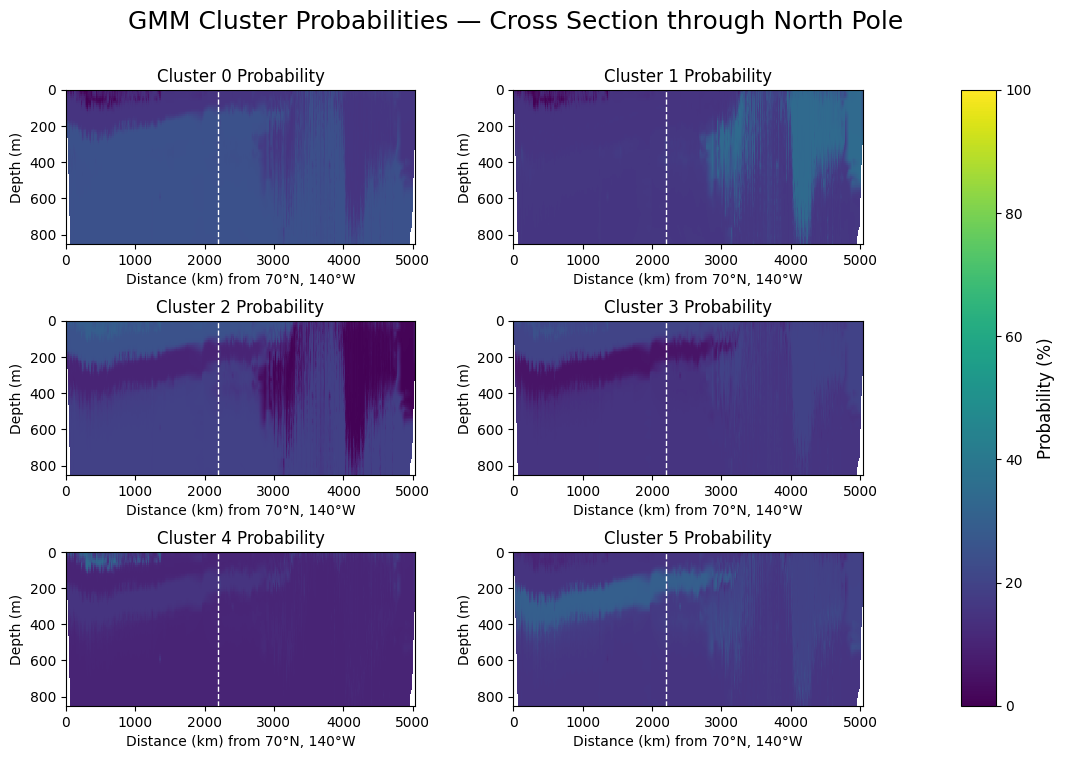

In [20]:
cross_sec_lon_prob2(df_new_copy, n_clusters, 0, tol=0.5, start_lat=70.0, start_lon=-140)